# Exploratory Data Analysis — Weather & Power Prices
**EDHEC MSc Data Analysis & AI — Power Price Forecasting Thesis**

This notebook explores the relationship between ERA5 weather variables and French day-ahead prices:
- Temperature, wind speed, solar radiation distributions
- Price vs temperature (heating demand effect)
- Price vs wind speed (renewable generation effect)
- Weather Stress Index analysis

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.config import INTERIM_DIR, FIGURES_DIR

sns.set_theme(style='whitegrid', palette='muted')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(INTERIM_DIR / 'merged.parquet')
print(f'{len(df):,} rows | {df.shape[1]} columns')
df[['price_da_eur_mwh','temperature_2m','wind_speed_10m','solar_radiation']].describe().round(2)

61,344 rows | 13 columns


,price_da_eur_mwh,temperature_2m,wind_speed_10m,solar_radiation
count,61344.00,61343.00,61343.00,61343.00
mean,94.50,12.75,2.80,565485.94
std,104.34,6.02,1.49,789967.12
min,-134.94,-5.39,0.01,0.00
25%,36.37,8.04,1.67,0.00
50%,57.88,12.23,2.62,46896.39
75%,107.21,17.33,3.74,974039.88
max,2987.78,31.65,9.24,3221349.50


## 1. Weather Variables Overview

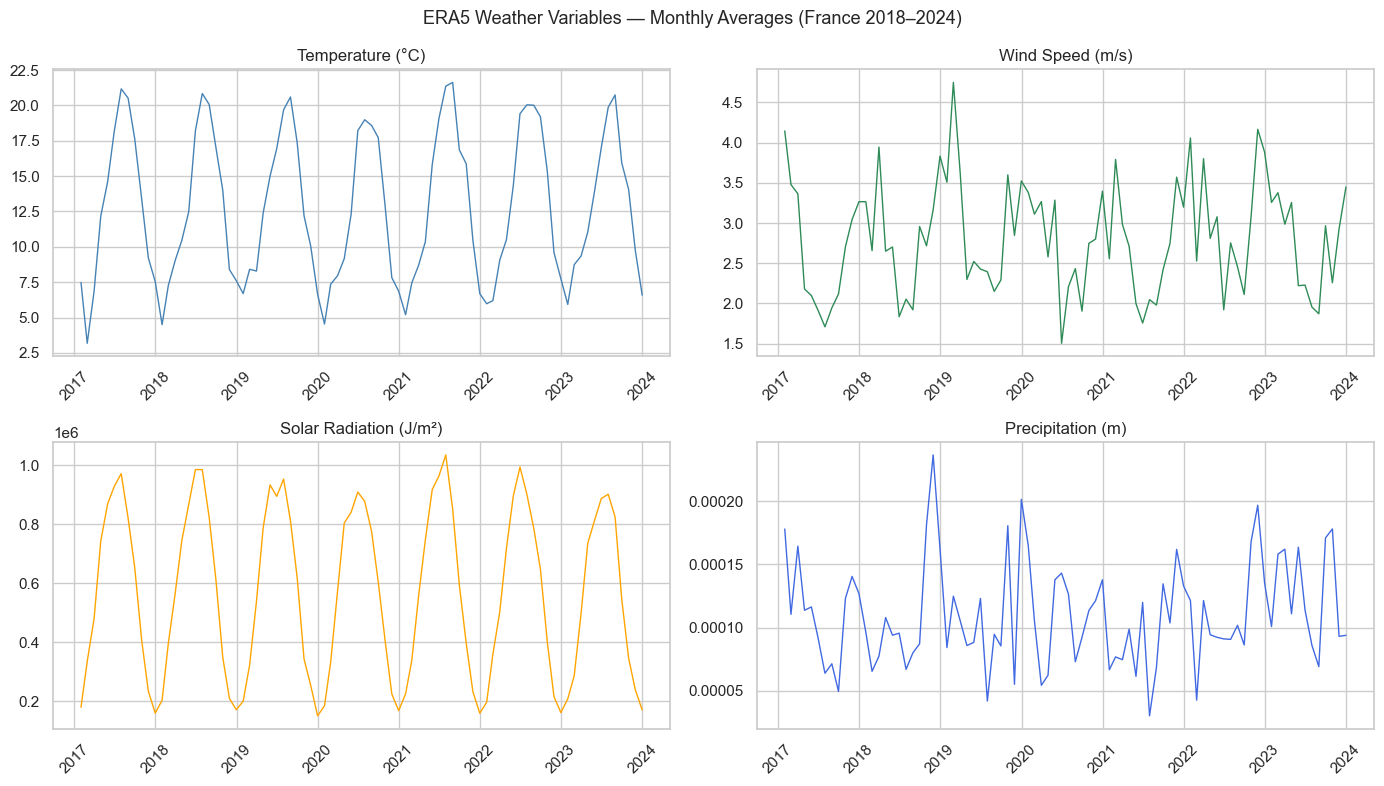

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

weather_cols = {
    'temperature_2m': ('Temperature (°C)', 'steelblue'),
    'wind_speed_10m': ('Wind Speed (m/s)', 'seagreen'),
    'solar_radiation': ('Solar Radiation (J/m²)', 'orange'),
    'precipitation': ('Precipitation (m)', 'royalblue'),
}

for ax, (col, (label, color)) in zip(axes.flat, weather_cols.items()):
    if col in df.columns:
        monthly = df[col].resample('ME').mean()
        ax.plot(monthly.index, monthly.values, color=color, linewidth=1)
        ax.set_title(label)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

fig.suptitle('ERA5 Weather Variables — Monthly Averages (France 2018–2024)', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'weather_overview.png', dpi=150)
plt.show()

## 2. Temperature vs Price

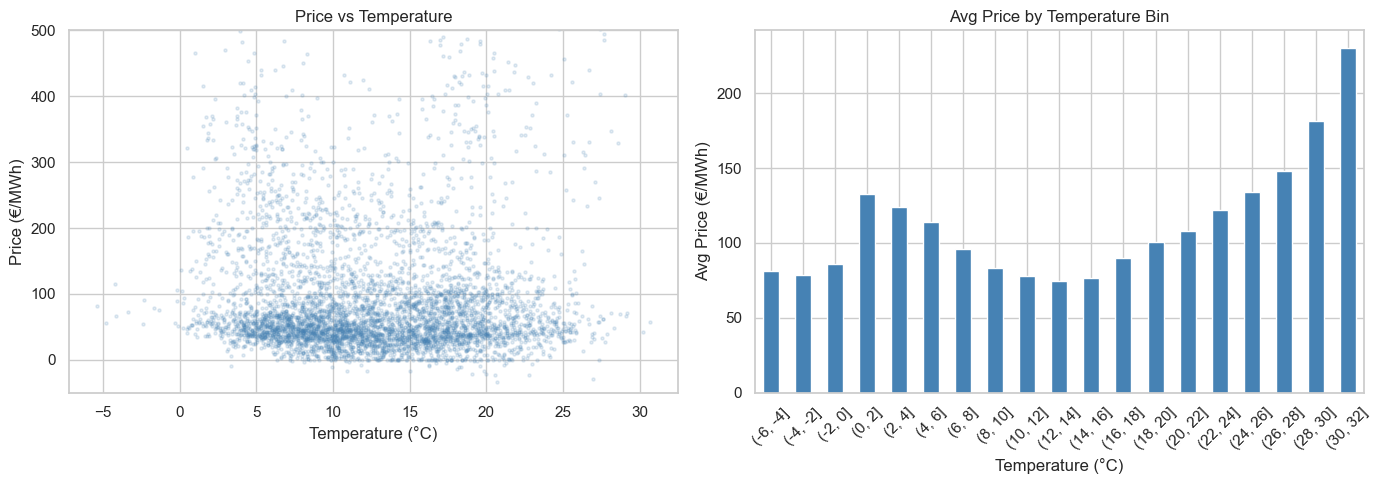

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
sample = df[['price_da_eur_mwh','temperature_2m']].dropna().sample(5000, random_state=42)
axes[0].scatter(sample['temperature_2m'], sample['price_da_eur_mwh'],
                alpha=0.15, s=5, color='steelblue')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Price (€/MWh)')
axes[0].set_title('Price vs Temperature')
axes[0].set_ylim(-50, 500)

# Avg price by temperature bin
df['temp_bin'] = pd.cut(df['temperature_2m'], bins=range(-10, 36, 2))
avg_by_temp = df.groupby('temp_bin', observed=True)['price_da_eur_mwh'].mean()
avg_by_temp.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Avg Price by Temperature Bin')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Avg Price (€/MWh)')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'price_vs_temperature.png', dpi=150)
plt.show()

## 3. Wind Speed vs Price

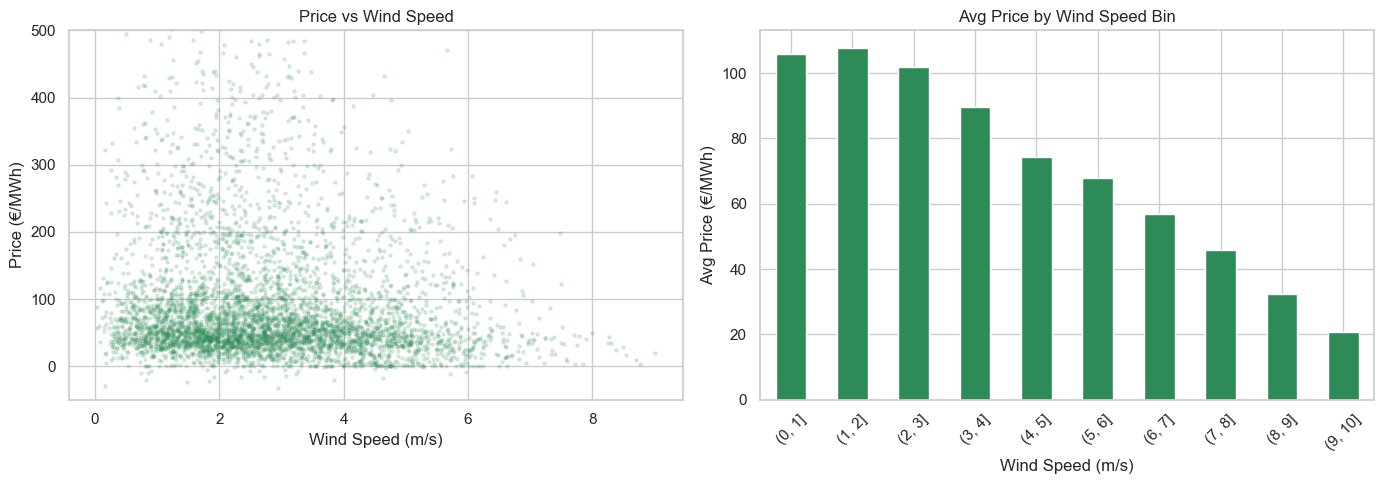

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df[['price_da_eur_mwh','wind_speed_10m']].dropna().sample(5000, random_state=42)
axes[0].scatter(sample['wind_speed_10m'], sample['price_da_eur_mwh'],
                alpha=0.15, s=5, color='seagreen')
axes[0].set_xlabel('Wind Speed (m/s)')
axes[0].set_ylabel('Price (€/MWh)')
axes[0].set_title('Price vs Wind Speed')
axes[0].set_ylim(-50, 500)

df['wind_bin'] = pd.cut(df['wind_speed_10m'], bins=np.arange(0, 12, 1))
avg_by_wind = df.groupby('wind_bin', observed=True)['price_da_eur_mwh'].mean()
avg_by_wind.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Avg Price by Wind Speed Bin')
axes[1].set_xlabel('Wind Speed (m/s)')
axes[1].set_ylabel('Avg Price (€/MWh)')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'price_vs_wind.png', dpi=150)
plt.show()

## 4. Heating Degree Days (HDD) vs Price

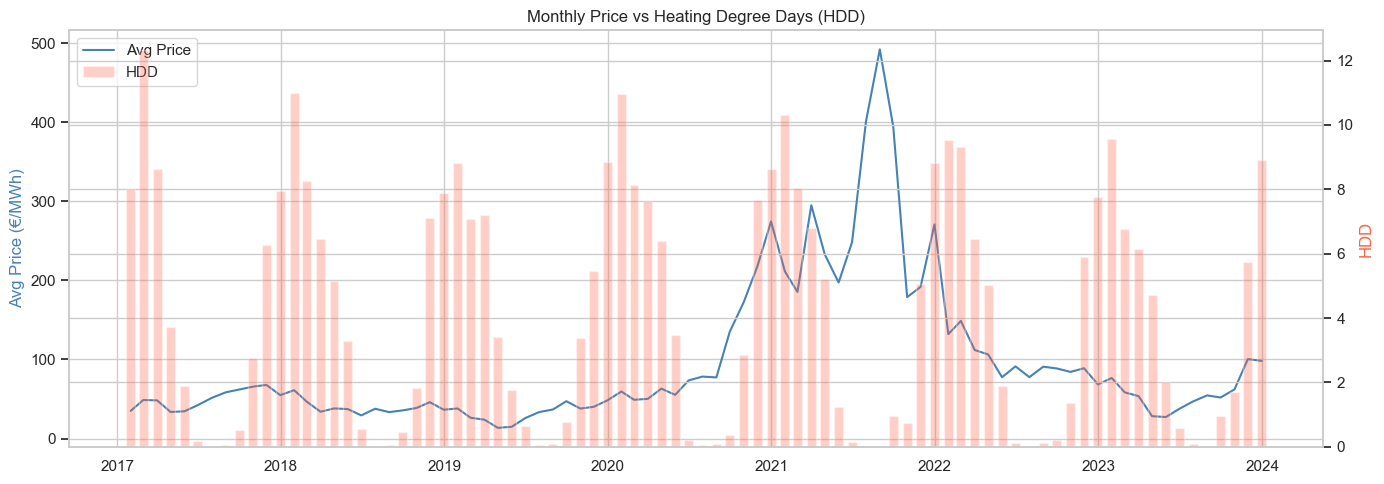

In [5]:
df['hdd'] = np.maximum(0, 15.5 - df['temperature_2m'])

monthly = df[['price_da_eur_mwh','hdd']].resample('ME').mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(monthly.index, monthly['price_da_eur_mwh'], color='steelblue', label='Avg Price')
ax2.bar(monthly.index, monthly['hdd'], alpha=0.3, color='tomato', width=20, label='HDD')

ax1.set_ylabel('Avg Price (€/MWh)', color='steelblue')
ax2.set_ylabel('HDD', color='tomato')
ax1.set_title('Monthly Price vs Heating Degree Days (HDD)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'price_vs_hdd.png', dpi=150)
plt.show()

## 5. Weather Stress Index

Correlation Price / Weather Stress Index: 0.059


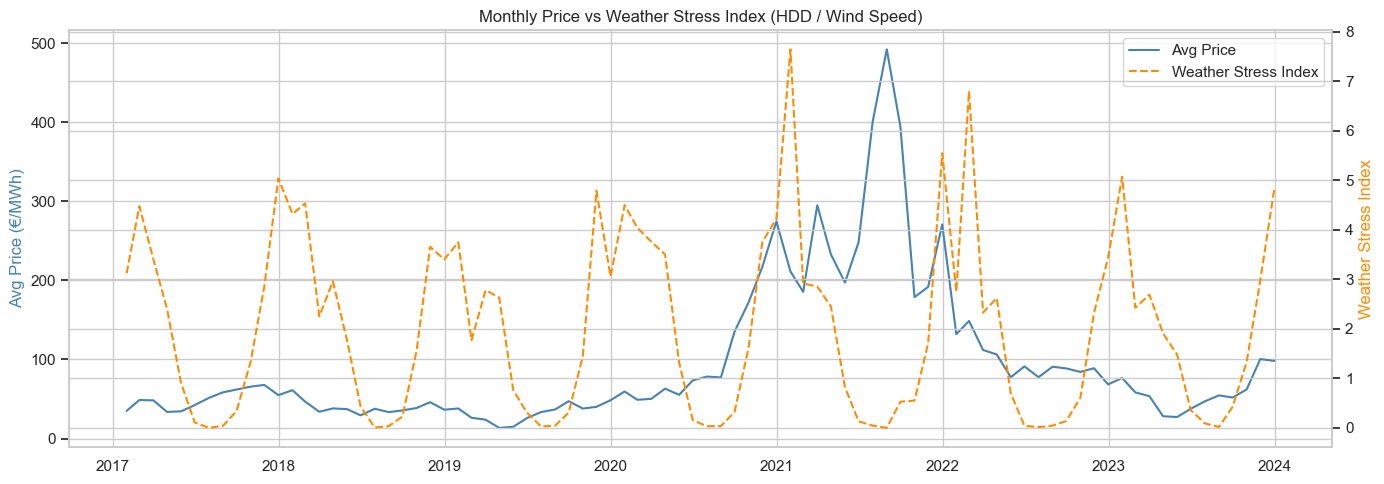

In [6]:
df['weather_stress_index'] = df['hdd'] / df['wind_speed_10m'].clip(lower=0.1)

monthly = df[['price_da_eur_mwh','weather_stress_index']].resample('ME').mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(monthly.index, monthly['price_da_eur_mwh'], color='steelblue', label='Avg Price')
ax2.plot(monthly.index, monthly['weather_stress_index'], color='darkorange',
         linestyle='--', label='Weather Stress Index')

ax1.set_ylabel('Avg Price (€/MWh)', color='steelblue')
ax2.set_ylabel('Weather Stress Index', color='darkorange')
ax1.set_title('Monthly Price vs Weather Stress Index (HDD / Wind Speed)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

corr = df[['price_da_eur_mwh','weather_stress_index']].corr().iloc[0,1]
print(f'Correlation Price / Weather Stress Index: {corr:.3f}')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'weather_stress_index.png', dpi=150)
plt.show()

## 6. Seasonality of Weather Variables

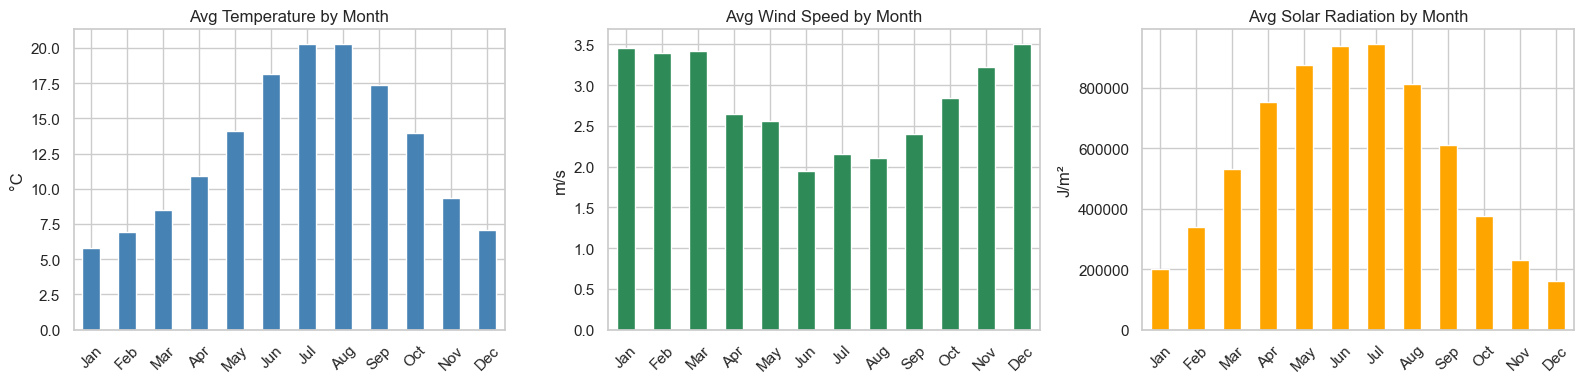

In [7]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['temperature_2m'].groupby(df.index.month).mean().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Temperature by Month')
axes[0].set_xticklabels(months, rotation=45)
axes[0].set_ylabel('°C')

df['wind_speed_10m'].groupby(df.index.month).mean().plot(
    kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Avg Wind Speed by Month')
axes[1].set_xticklabels(months, rotation=45)
axes[1].set_ylabel('m/s')

df['solar_radiation'].groupby(df.index.month).mean().plot(
    kind='bar', ax=axes[2], color='orange')
axes[2].set_title('Avg Solar Radiation by Month')
axes[2].set_xticklabels(months, rotation=45)
axes[2].set_ylabel('J/m²')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'weather_seasonality.png', dpi=150)
plt.show()

## 7. Full Correlation Matrix — All Features

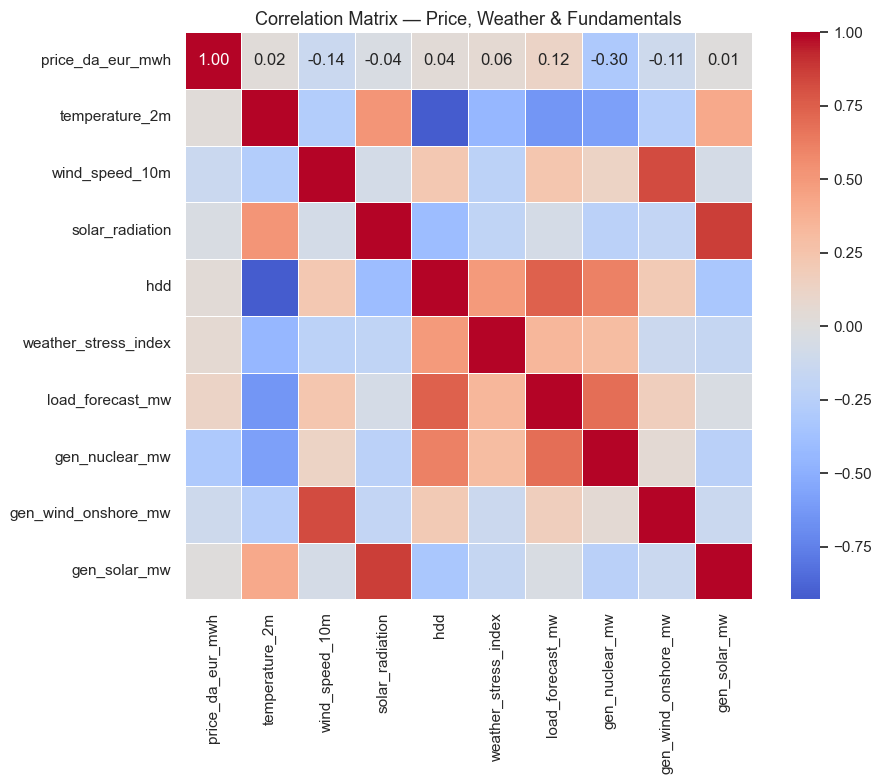

In [8]:
cols = ['price_da_eur_mwh', 'temperature_2m', 'wind_speed_10m',
        'solar_radiation', 'hdd', 'weather_stress_index',
        'load_forecast_mw', 'gen_nuclear_mw', 'gen_wind_onshore_mw', 'gen_solar_mw']
cols = [c for c in cols if c in df.columns]

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — Price, Weather & Fundamentals', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'correlation_full.png', dpi=150)
plt.show()